# M6 — Notebook 02 · Dynamic satellite layers (batch C)

**Batch C of the 16 M6 geomatics variables** — the only ones that change week to week.

| # | Variable | Product | Cadence | Native res |
|---|---|---|---|---|
| 9  | Land surface temperature, day + night | MOD11A2 (Terra) | 8-day | 1 km |
| 10 | NDVI and EVI greenness | MOD13Q1 (Terra) | 16-day | 250 m |

### Why this notebook decides whether M6 is a real test

Batch A (terrain) and most of batch B are **static** — one value per district, forever. A model
built only from those emits one constant prediction per district for every week of the series.
Against a *weekly* elevated-activity label it can say **which** districts differ but never
**when**, so it scores near chance **by construction**. That null would be an artefact of the
feature set, not a finding about geomatics.

These two products are what give M6 a time axis. Section 15 measures directly how much of each
layer's variance is temporal rather than cross-sectional — if that fraction were near zero, M6
would be untestable and we would need to say so rather than report the null.

### What this notebook does

1. Assert we are on the frame notebooks 00 and 01 validated
2. Select **Terra only** — the collection silently contains Aqua as well (§4)
3. Snap a working grid to the **native MODIS sinusoidal grid** so the data is never resampled (§5)
4. Choose a QA filter by measuring what each option throws away, rather than by convention (§8)
5. Reduce every composite to the 26 RDHS units, carrying coverage alongside the mean
6. Inspect the series — seasonality, gaps, and the between-unit / over-time variance split
7. Freeze both tables with a provenance record

**No account, no API key.** Microsoft Planetary Computer signs blob access anonymously.

---

## 1 · Setup, and assert the chain

In [1]:
import json, hashlib, time
from pathlib import Path
from collections import namedtuple

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.features
from rasterio.windows import from_bounds, Window
import pystac_client
import planetary_computer as pc
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((QUAR / "nb00_provenance.json").read_text())
prov1 = json.loads((QUAR / "nb01_provenance.json").read_text())

rdhs = gpd.read_file(GEOM)
sha_now = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]

assert sha_now == prov0["geometry_sha256_16"], "geometry changed since notebook 00 — stop"
assert len(rdhs) == prov0["n_units"] == 26
assert prov1["geometry_sha256_16"] == sha_now, "notebook 01 ran on a different geometry — stop"

N_UNITS = len(rdhs)
SEED = prov0["seed"]

print("frame verified against notebooks 00 and 01")
print("  geometry sha256 :", sha_now)
print("  units           :", N_UNITS)
print("  batch A features:", prov1["n_features"], "->", prov1["output_sha256_16"])

frame verified against notebooks 00 and 01
  geometry sha256 : 9e5e2c0a541ecac1
  units           : 26
  batch A features: 21 -> 1ef4bc27298b7082


## 2 · The window

The Sri Lanka analysis window is **2018–2025** (`docs/M6.md` §6). We pull from **2017-11-01** so
that the longest lag the model may use (8 weeks, mirroring M2's climate lag design) is available
for the very first epi-week of 2018 — otherwise the first two months of the series would silently
carry truncated lags.

The pre-roll is *past* data relative to every modelled week. It introduces no leakage: nothing
here reaches forward. The leakage risk in this notebook is the opposite direction — a composite
that spans dates *after* the week it is joined to — and that is handled in assembly (notebook 04)
by keying on the composite's **start** date and never letting a composite inform a week it
overlaps into. Section 16 records the start/end of every composite so that join can be made
correctly.

In [2]:
WIN_START, WIN_END = "2017-11-01", "2025-12-31"
BBOX = list(rdhs.total_bounds)          # island bbox in EPSG:4326

STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
# Open WITHOUT a signing modifier: hrefs are signed lazily at read time instead. A SAS token
# minted during the search would expire part-way through a 40-minute extraction loop.
cat = pystac_client.Client.open(STAC)

print("window :", WIN_START, "->", WIN_END)
print("bbox   :", [round(v, 3) for v in BBOX])

window : 2017-11-01 -> 2025-12-31
bbox   : [np.float64(79.521), np.float64(5.919), np.float64(81.879), np.float64(9.836)]


## 3 · Which MODIS tiles actually cover the island

A bounding-box search returns four tiles (h25/h26 × v07/v08). MODIS sinusoidal tile footprints
are curved in lon/lat, so two of them only *appear* to intersect the box. Rather than hardcode
the answer, open one granule per tile and test the real raster extent against the geometry.

In [3]:
probe = list(cat.search(collections=["modis-11A2-061"], bbox=BBOX,
                        datetime="2020-06-01/2020-06-10").items())
seen, TILES = {}, []
for i in probe:
    key = (i.properties["modis:horizontal-tile"], i.properties["modis:vertical-tile"])
    seen.setdefault(key, i)

for key, item in sorted(seen.items()):
    with rasterio.open(pc.sign(item.assets["LST_Day_1km"].href)) as s:
        b = s.bounds
        gb = rdhs.to_crs(s.crs).total_bounds
        overlaps = gb[0] < b.right and gb[2] > b.left and gb[1] < b.top and gb[3] > b.bottom
    print(f"  h{key[0]:02d}v{key[1]:02d}  x[{b.left:>10.0f},{b.right:>10.0f}]  "
          f"y[{b.bottom:>9.0f},{b.top:>9.0f}]  overlaps island: {overlaps}")
    if overlaps:
        TILES.append(key)

print("\ntiles kept:", TILES)
assert len(TILES) == 2, TILES

  h25v08  x[   7783654,   8895604]  y[        0,  1111951]  overlaps island: True


  h26v08  x[   8895604,  10007555]  y[        0,  1111951]  overlaps island: True

tiles kept: [(25, 8), (26, 8)]


## 4 · The Terra / Aqua trap

`modis-11A2-061` and `modis-13Q1-061` each hold **two platforms**: Terra (`MOD*`, ~10:30 local
overpass) and Aqua (`MYD*`, ~13:30). They are different products with different thermal sampling
times — Aqua's daytime pass sits much closer to the diurnal maximum.

Grouping items by (date, tile) without checking would hand you whichever the catalogue listed
first, so an LST series could switch platforms mid-record and the discontinuity would look like
climate. Below, the same date returns items from both.

`docs/M6.md` §Batch C specifies **MOD11A2 / MOD13Q1 — Terra**, so Terra is what we take. Aqua is
left on the table deliberately; it is a legitimate gap-filling sensitivity for later (it would
roughly halve the cloud gaps quantified in §14) but combining platforms into one column is not.

Select on the **product id prefix**, not the STAC `platform` field — that field is empty for some
items in this collection.

In [4]:
for i in sorted(probe, key=lambda x: x.id)[:6]:
    print(f"  {i.id:<45} platform={i.properties.get('platform','')!r:8} "
          f"start={i.properties['start_datetime'][:10]}")

plats = sorted({i.properties.get("platform", "") for i in probe})
print("\ndistinct `platform` values in this collection:", plats)

  MOD11A2.A2020153.h25v08.061.2021011180531     platform='terra'  start=2020-06-01
  MOD11A2.A2020153.h26v08.061.2021011180620     platform='terra'  start=2020-06-01
  MOD11A2.A2020161.h25v08.061.2021011181723     platform='terra'  start=2020-06-09
  MOD11A2.A2020161.h26v08.061.2021011181706     platform='terra'  start=2020-06-09
  MYD11A2.A2020153.h25v08.061.2021011180459     platform='aqua'   start=2020-06-01
  MYD11A2.A2020153.h26v08.061.2021011180453     platform='aqua'   start=2020-06-01

distinct `platform` values in this collection: ['aqua', 'terra']


In [5]:
def terra_composites(collection, product):
    """Every Terra composite over the island: {start_date: [item per tile]}.

    Two guards, both needed:
      - keep only `product` (MOD*, never MYD*) — see the note above
      - a few (date, tile) pairs appear twice as reprocessing versions; keep the newest
        `created`, deterministically, rather than whichever arrived first
    """
    items = [i for i in cat.search(collections=[collection], bbox=BBOX,
                                   datetime=f"{WIN_START}/{WIN_END}").items()
             if i.id.startswith(product)
             and (i.properties["modis:horizontal-tile"],
                  i.properties["modis:vertical-tile"]) in TILES]

    best, n_dupe = {}, 0
    for i in items:
        key = (i.properties["start_datetime"][:10], i.properties["modis:horizontal-tile"])
        prev = best.get(key)
        if prev is None:
            best[key] = i
        else:
            n_dupe += 1
            if i.properties.get("created", "") > prev.properties.get("created", ""):
                best[key] = i

    out = {}
    for (date, _tile), i in sorted(best.items()):
        out.setdefault(date, []).append(i)

    print(f"{product}: {len(items)} items -> {len(out)} composites "
          f"({n_dupe} reprocessing duplicates resolved to newest)")
    partial = {d: len(v) for d, v in out.items() if len(v) != len(TILES)}
    if partial:
        print(f"  WARNING composites missing a tile: {partial}")
    return out

t0 = time.time()
lst_comp  = terra_composites("modis-11A2-061", "MOD11A2")
ndvi_comp = terra_composites("modis-13Q1-061", "MOD13Q1")
print(f"\ncatalogue queried in {time.time()-t0:.0f}s")

MOD11A2: 721 items -> 350 composites (21 reprocessing duplicates resolved to newest)


MOD13Q1: 365 items -> 177 composites (12 reprocessing duplicates resolved to newest)
  WARNING composites missing a tile: {'2025-04-07': 1}

catalogue queried in 8s


## 5 · The grid — work in MODIS's own projection

The obvious move is to warp each composite into the equal-area CRS from notebook 00. Don't:

- **Resampling is lossy and repeated.** 350 composites × 2 products, each interpolated, before
  any statistic is taken. Zonal means over a district are insensitive to the projection but
  sensitive to having invented pixel values.
- **Sinusoidal is already equal-area.** Every MODIS pixel covers the same ground area, which is
  exactly the property a zonal mean needs. Notebook 00's LAEA CRS was chosen for the same reason;
  here we get it for free.
- **The tiles share one grid**, so a mosaic window snapped to it is exact — a pure array copy.

So the geometry is reprojected to the *data*, once, instead of the data being reprojected to the
geometry 700 times.

In [6]:
Grid = namedtuple("Grid", "crs res left top H W transform")

def snap_grid(href, pad=2):
    """Snap a small mosaic window to the native MODIS grid the granule sits on."""
    with rasterio.open(pc.sign(href)) as s:
        crs, T, res = s.crs, s.transform, s.res[0]
    minx, miny, maxx, maxy = rdhs.to_crs(crs).total_bounds
    left = T.c + np.floor((minx - T.c) / res) * res - pad * res   # grid line <= minx
    top  = T.f - np.floor((T.f - maxy) / res) * res + pad * res   # grid line >= maxy
    W = int(np.ceil((maxx - left) / res)) + pad
    H = int(np.ceil((top - miny) / res)) + pad
    return Grid(crs, res, left, top, H, W,
                rasterio.transform.from_origin(left, top, res, res))

ref_lst  = lst_comp[sorted(lst_comp)[0]][0].assets["LST_Day_1km"].href
ref_ndvi = ndvi_comp[sorted(ndvi_comp)[0]][0].assets["250m_16_days_NDVI"].href
G1K  = snap_grid(ref_lst)
G250 = snap_grid(ref_ndvi)

for name, g in [("LST  1 km", G1K), ("NDVI 250 m", G250)]:
    print(f"{name}: {g.H} x {g.W} px  res {g.res:.2f} m  "
          f"extent {g.W*g.res/1000:.0f} x {g.H*g.res/1000:.0f} km")
print("\nCRS:", G1K.crs.to_string()[:60], "...")
assert G1K.crs == G250.crs

LST  1 km: 475 x 342 px  res 926.63 m  extent 317 x 440 km
NDVI 250 m: 1886 x 1354 px  res 231.66 m  extent 314 x 437 km

CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom ...


## 6 · Rasterize the 26 units onto each grid

Done **once** per grid, then reused for every composite — the per-composite work collapses to a
windowed read and a `bincount`. Coarse grids are where zonal statistics quietly break, so check
the two failure modes before trusting anything: a unit with too few pixels to have a stable mean,
and total rasterized area drifting from the vector area.

In [7]:
def rasterize_units(g):
    z = rasterio.features.rasterize(
        ((geom, i + 1) for i, geom in enumerate(rdhs.to_crs(g.crs).geometry)),
        out_shape=(g.H, g.W), transform=g.transform, fill=0, dtype="uint16")
    return z, np.bincount(z.ravel(), minlength=N_UNITS + 1)[1:]

zones1k,  npx1k  = rasterize_units(G1K)
zones250, npx250 = rasterize_units(G250)

area = pd.DataFrame({
    "rdhs_name": rdhs["rdhs_name"],
    "px_1km":    npx1k,
    "px_250m":   npx250,
    "area_1km_km2":  npx1k  * G1K.res ** 2 / 1e6,
    "area_250m_km2": npx250 * G250.res ** 2 / 1e6,
    "area_vector_km2": rdhs.to_crs(prov0["crs_equal_area"]).area / 1e6,
})
area["err_1km_%"]  = 100 * (area["area_1km_km2"]  / area["area_vector_km2"] - 1)
area["err_250m_%"] = 100 * (area["area_250m_km2"] / area["area_vector_km2"] - 1)

print("smallest unit :", area.loc[area.px_1km.idxmin(), "rdhs_name"],
      "-", int(area.px_1km.min()), "px at 1 km")
print("units < 100 px at 1 km:", int((area.px_1km < 100).sum()))
print(f"total area  1 km grid: {area.area_1km_km2.sum():,.0f} km2   "
      f"250 m grid: {area.area_250m_km2.sum():,.0f} km2   "
      f"vector: {area.area_vector_km2.sum():,.0f} km2")
print(f"worst per-unit area error: 1 km {area['err_1km_%'].abs().max():.1f}%   "
      f"250 m {area['err_250m_%'].abs().max():.1f}%")

assert area.px_1km.min() >= 100, "a unit is too small for a stable 1 km zonal mean"
area.sort_values("px_1km").head(5).round(1)

smallest unit : Colombo - 807 px at 1 km
units < 100 px at 1 km: 0
total area  1 km grid: 66,318 km2   250 m grid: 66,324 km2   vector: 66,041 km2
worst per-unit area error: 1 km 0.9%   250 m 0.5%


,rdhs_name,px_1km,px_250m,area_1km_km2,area_250m_km2,area_vector_km2,err_1km_%,err_250m_%
0,Colombo,807,12880,692.9,691.2,688.2,0.7,0.4
24,Kalmunai,1235,19691,1060.4,1056.7,1051.9,0.8,0.5
9,Jaffna,1269,20444,1089.6,1097.1,1091.2,-0.1,0.5
7,Matara,1527,24447,1311.1,1311.9,1306.4,0.4,0.4
13,Killinochchi,1539,24679,1321.4,1324.4,1319.3,0.2,0.4


The 1 km grid loses area on small coastal units — Colombo is the extreme case — because a pixel
is assigned whole to whichever unit contains its centre. That is a resolution limit, not an error
to correct: a 1 km thermal pixel over a district that narrow genuinely mixes in its neighbours.
It is recorded here so the LST column for those units can be read with the right scepticism, and
it is one more reason the 250 m greenness grid carries the finer spatial detail.

Look at the zones before using them — a rasterization that silently dropped or shifted a unit is
obvious in a picture and invisible in a table.

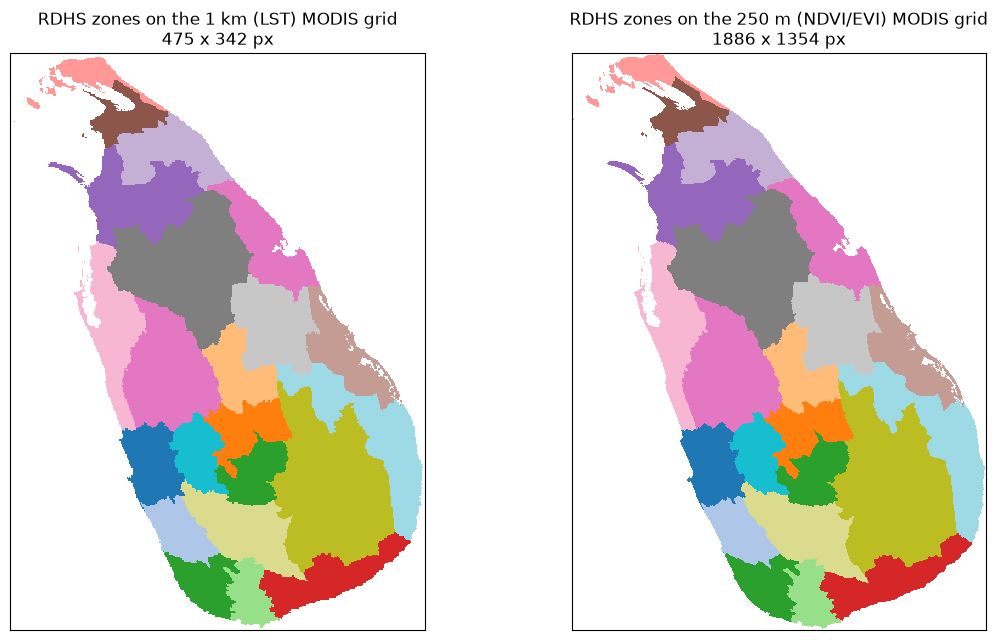

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))
for ax, (z, g, t) in zip(axes, [(zones1k, G1K, "1 km (LST)"),
                                (zones250, G250, "250 m (NDVI/EVI)")]):
    ax.imshow(np.where(z == 0, np.nan, z), cmap="tab20", interpolation="nearest")
    ax.set_title(f"RDHS zones on the {t} MODIS grid\n{g.H} x {g.W} px")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

## 7 · Reading a composite

Two tiles have to be stitched. The tempting shortcut is a boundless read filled with a sentinel
and "first non-sentinel wins", but the QA bands make that unsafe: `0` and `255` are both *legal*
QC values, so a sentinel cannot be distinguished from data. Instead each tile is placed by its
true extent, and a separate boolean tracks what was actually covered.

The retry is not decoration — this loop makes ~3,500 network reads and a single transient failure
40 minutes in would otherwise cost the whole run.

In [9]:
def _read_window(href, g):
    """One tile -> (subarray, dest_row, dest_col), or None if it misses the window."""
    with rasterio.open(pc.sign(href)) as s:            # sign at read time, never earlier
        w = from_bounds(g.left, g.top - g.H * g.res, g.left + g.W * g.res, g.top,
                        transform=s.transform).round_offsets().round_lengths()
        c0, r0 = max(0, int(w.col_off)), max(0, int(w.row_off))
        c1 = min(s.width,  int(w.col_off + w.width))
        r1 = min(s.height, int(w.row_off + w.height))
        if c1 <= c0 or r1 <= r0:
            return None
        sub = s.read(1, window=Window(c0, r0, c1 - c0, r1 - r0))
    return sub, r0 - int(w.row_off), c0 - int(w.col_off)


def read_placed(hrefs, g, dtype="int32", tries=3):
    """Mosaic tiles into the grid by extent. Returns (array, covered_mask)."""
    out = np.zeros((g.H, g.W), dtype=dtype)
    got = np.zeros((g.H, g.W), dtype=bool)
    for href in hrefs:
        for k in range(tries):
            try:
                r = _read_window(href, g)
                break
            except Exception:
                if k == tries - 1:
                    raise
                time.sleep(2 ** k)
        if r is None:
            continue
        sub, dr, dc = r
        out[dr:dr + sub.shape[0], dc:dc + sub.shape[1]] = sub
        got[dr:dr + sub.shape[0], dc:dc + sub.shape[1]] = True
    return out, got


d0 = sorted(lst_comp)[len(lst_comp) // 2]          # a mid-record composite
items0 = lst_comp[d0]
t0 = time.time()
lst0, got0 = read_placed([i.assets["LST_Day_1km"].href for i in items0], G1K)
qc0,  _    = read_placed([i.assets["QC_Day"].href      for i in items0], G1K)
land1k = zones1k > 0

print(f"composite {d0}: read in {time.time()-t0:.1f}s")
print(f"  land pixels covered by tiles : {got0[land1k].mean():.2%}")
print(f"  LST DN range (non-fill)      : {lst0[lst0>0].min()} .. {lst0.max()}")
print(f"  -> degC                      : {lst0[lst0>0].min()*0.02-273.15:.1f} .. "
      f"{lst0.max()*0.02-273.15:.1f}")
assert got0[land1k].all(), "some land pixels were not covered by any tile"

composite 2021-08-21: read in 1.9s
  land pixels covered by tiles : 100.00%
  LST DN range (non-fill)      : 13846 .. 15877
  -> degC                      : 3.8 .. 44.4


## 8 · Choosing the QA filter by measuring it

MOD11A2 packs quality into `QC_Day` / `QC_Night`: bits 0–1 are mandatory QA (`0` good, `1`
produced but check further, `2`/`3` not produced — cloud), and bits 6–7 bound the average LST
error (`0` ≤1 K, `1` ≤2 K, `2` ≤3 K, `3` >3 K).

The instinct is to keep only mandatory QA `0`. Measure what that costs before adopting it — in a
monsoon climate the strictest filter is not the most honest one, because the pixels it discards
are not missing at random. They are the cloudy, wet, humid weeks, which is to say precisely the
weeks a dengue model cares about. Throwing them away biases the series warm and dry.

In [10]:
mand0 = qc0 & 0b11           # bits 0-1: mandatory QA
err0  = (qc0 >> 6) & 0b11    # bits 6-7: average LST error

options = [
    ("no filter (non-fill only)",     lst0 > 0),
    ("mandatory QA == 0",             (lst0 > 0) & (mand0 == 0)),
    ("mandatory QA <= 1",             (lst0 > 0) & (mand0 <= 1)),
    ("mandatory QA <= 1 & err <= 2K", (lst0 > 0) & (mand0 <= 1) & (err0 <= 1)),
    ("mandatory QA <= 1 & err <= 3K", (lst0 > 0) & (mand0 <= 1) & (err0 <= 2)),
]
qa_table = []
for lab, keep in options:
    c = np.where(keep & land1k, lst0 * 0.02 - 273.15, np.nan)
    units = len(np.unique(zones1k[np.isfinite(c)]))
    qa_table.append({"filter": lab,
                     "land px kept": f"{(keep & land1k).sum()/land1k.sum():.1%}",
                     "units with data": f"{units}/{N_UNITS}",
                     "mean degC": round(float(np.nanmean(c)), 2) if np.isfinite(c).any() else None})
pd.DataFrame(qa_table)

,filter,land px kept,units with data,mean degC
0,no filter (non-fill only),52.5%,26/26,29.49
1,mandatory QA == 0,11.3%,23/26,30.68
2,mandatory QA <= 1,52.5%,26/26,29.49
3,mandatory QA <= 1 & err <= 2K,52.4%,26/26,29.49
4,mandatory QA <= 1 & err <= 3K,52.5%,26/26,29.49


**Filter adopted: mandatory QA ≤ 1 with average error ≤ 2 K.**

Mandatory QA `0` alone retains a small minority of land pixels on this composite and leaves
whole districts empty — it is not a usable time series. Relaxing to `≤ 1` recovers nearly
everything, and the error-bits condition is what keeps that honest: it drops the retrievals the
product itself flags as worse than 2 K rather than accepting anything that was merely produced.
This is the standard MOD11A2 usage, and here it is adopted because it was measured, not because
it is standard.

Whatever survives the filter, **the per-unit coverage fraction is carried in the output** so
downstream work can see which values rest on a handful of pixels. Section 14 audits it.

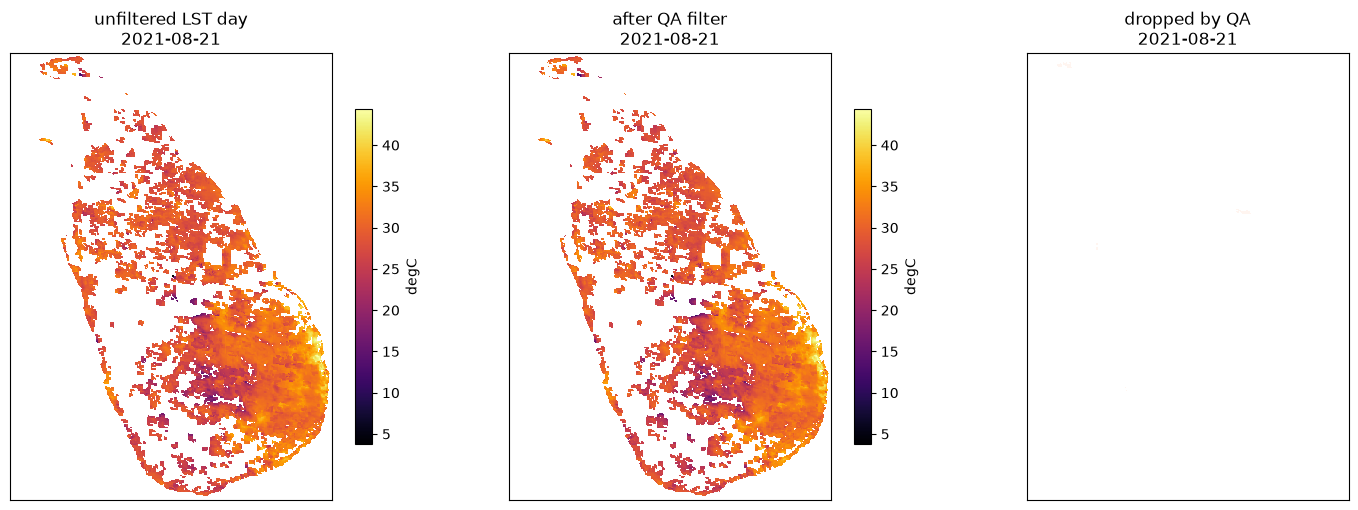

In [11]:
def lst_celsius(dn, qc, got):
    """Scale to degC, keeping only QA-acceptable retrievals inside covered ground.

    `got` is not redundant: a pixel no tile covered reads as 0, and for some bands 0 is a
    legal value. Requiring coverage explicitly means an un-stitched corner can never be
    mistaken for data.
    """
    ok = got & (dn > 0) & ((qc & 0b11) <= 1) & (((qc >> 6) & 0b11) <= 1)
    return np.where(ok, dn * 0.02 - 273.15, np.nan)

c0 = lst_celsius(lst0, qc0, got0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
raw = np.where((lst0 > 0) & land1k, lst0 * 0.02 - 273.15, np.nan)
kept = np.where(land1k, c0, np.nan)
for ax, (a, t) in zip(axes, [(raw, "unfiltered LST day"),
                             (kept, "after QA filter"),
                             (np.where(land1k & np.isnan(c0) & (lst0 > 0), 1, np.nan),
                              "dropped by QA")]):
    im = ax.imshow(a, cmap="inferno" if "dropped" not in t else "Reds",
                   interpolation="nearest")
    ax.set_title(f"{t}\n{d0}"); ax.set_xticks([]); ax.set_yticks([])
    if "dropped" not in t:
        plt.colorbar(im, ax=ax, shrink=0.75, label="degC")
plt.tight_layout()

## 9 · Reducing to the 26 units

`bincount` over the zone raster, which is the whole reduction: one pass, no per-polygon masking.
Notebook 01 carried five statistics per layer; for a series that is 350 composites long the mean,
the within-unit SD and the **coverage fraction** are what earn their place — per-composite
percentiles would multiply the table without changing a weekly model.

Coverage is not optional bookkeeping. A unit mean over 4% of its pixels is a different quantity
from one over 95%, and without the column they are indistinguishable in the CSV.

In [12]:
def zonal(arr, zones, npx):
    """Per-unit mean, SD and valid-pixel fraction. NaN in `arr` means masked out."""
    ok = np.isfinite(arr) & (zones > 0)
    z = zones[ok].astype(np.int64)
    v = arr[ok].astype(np.float64)
    n  = np.bincount(z, weights=None,  minlength=N_UNITS + 1)[1:]
    s  = np.bincount(z, weights=v,     minlength=N_UNITS + 1)[1:]
    ss = np.bincount(z, weights=v * v, minlength=N_UNITS + 1)[1:]
    mean = np.where(n > 0, s / np.maximum(n, 1), np.nan)
    sd   = np.where(n > 1, np.sqrt(np.maximum(ss / np.maximum(n, 1) - mean ** 2, 0)), np.nan)
    return mean, sd, n / np.maximum(npx, 1)

m, sd, frac = zonal(c0, zones1k, npx1k)
check = pd.DataFrame({"rdhs_name": rdhs["rdhs_name"], "lst_day": m,
                      "sd": sd, "coverage": frac}).sort_values("lst_day")

terrain = pd.read_csv(QUAR / "m6_batchA_terrain_srilanka.csv")
check = check.merge(terrain[["rdhs_name", "elev_mean"]], on="rdhs_name")

valid = check.dropna(subset=["lst_day"])
print(f"composite {d0}")
print("  coolest:", valid.iloc[0]["rdhs_name"], f"{valid.iloc[0]['lst_day']:.1f} degC",
      f"(elevation {valid.iloc[0]['elev_mean']:.0f} m)")
print("  warmest:", valid.iloc[-1]["rdhs_name"], f"{valid.iloc[-1]['lst_day']:.1f} degC",
      f"(elevation {valid.iloc[-1]['elev_mean']:.0f} m)")
r = valid["lst_day"].corr(valid["elev_mean"])
print(f"  corr(LST, elevation) = {r:.3f}   (lapse rate: must be strongly negative)")

# Loose thresholds on purpose. One 8-day composite is noisy: cloud decides which pixels
# survive QA, and land cover and coastal proximity compete with elevation. Sampling across
# the record, single-composite r runs from about -0.4 to -0.9. The strong version of this
# check is in section 11, on the averaged series, where that noise cancels.
assert "Nuwara Eliya" in set(valid.head(3)["rdhs_name"]), "highland is not among the coolest"
assert r < -0.3, "LST does not track elevation at all — suspect the grid or the scaling"
check.round(2)

composite 2021-08-21
  coolest: Nuwara Eliya 25.2 degC (elevation 1283 m)
  warmest: Kalmunai 36.7 degC (elevation 18 m)
  corr(LST, elevation) = -0.463   (lapse rate: must be strongly negative)


,rdhs_name,lst_day,sd,coverage,elev_mean
0,Nuwara Eliya,25.23,3.28,0.74,1283.32
1,Matale,26.47,4.45,0.45,347.31
2,Matara,26.48,2.02,0.36,152.66
3,Kalutara,26.73,2.11,0.25,63.90
4,Ratnapura,27.10,2.88,0.41,376.10
5,Galle,27.44,1.87,0.42,70.17
6,Vavuniya,27.66,1.83,0.28,76.76
7,Kegalle,27.72,2.80,0.40,267.28
8,Mullaitivu,27.83,1.47,0.29,38.47
9,Kandy,28.07,2.23,0.78,660.87


That correlation is the real check on everything above it. Elevation and LST were derived from
completely independent sources — a Copernicus DEM warped to LAEA in notebook 01, and MODIS
thermal data on a sinusoidal grid here — so a strong lapse-rate relationship between them can
only appear if both the grid alignment and the scaling are right. A transposed axis or a missing
×0.02 would destroy it.

## 10 · Extract the full LST record

~350 composites × 2 tiles × 4 bands ≈ 2,800 reads, so this is the slow cell (tens of minutes on
a first run). It writes through to a CSV cache every 25 composites and skips what is already
there, so an interruption costs at most the current chunk and a re-run is nearly free.

In [13]:
LST_CSV = QUAR / "m6_lst_terra_8day_srilanka.csv"

done = set()
if LST_CSV.exists():
    done = set(pd.read_csv(LST_CSV, usecols=["composite_start"])["composite_start"].astype(str))
todo = [d for d in sorted(lst_comp) if d not in done]
print(f"{len(done)} composites cached, {len(todo)} to fetch")

buf, t0 = [], time.time()
for k, date in enumerate(todo, 1):
    its = lst_comp[date]
    day, gd = read_placed([i.assets["LST_Day_1km"].href   for i in its], G1K)
    qcd, _  = read_placed([i.assets["QC_Day"].href        for i in its], G1K)
    ngt, gn = read_placed([i.assets["LST_Night_1km"].href for i in its], G1K)
    qcn, _  = read_placed([i.assets["QC_Night"].href      for i in its], G1K)

    md_, sdd, fd = zonal(lst_celsius(day, qcd, gd), zones1k, npx1k)
    mn_, sdn, fn = zonal(lst_celsius(ngt, qcn, gn), zones1k, npx1k)

    buf.append(pd.DataFrame({
        "composite_start": date,
        "composite_end":   its[0].properties["end_datetime"][:10],
        "rdhs_id":   rdhs["rdhs_id"].values,
        "rdhs_name": rdhs["rdhs_name"].values,
        "lst_day_mean": md_, "lst_day_sd": sdd, "lst_day_cov": fd,
        "lst_night_mean": mn_, "lst_night_sd": sdn, "lst_night_cov": fn,
    }))

    if k % 25 == 0 or k == len(todo):
        pd.concat(buf).to_csv(LST_CSV, mode="a", header=not LST_CSV.exists(), index=False)
        buf = []
        el = time.time() - t0
        print(f"  {k:>4}/{len(todo)}  {date}  {el/60:.1f} min elapsed, "
              f"~{el/k*(len(todo)-k)/60:.0f} min left")

lst = pd.read_csv(LST_CSV).drop_duplicates(["composite_start", "rdhs_id"])
lst["composite_start"] = pd.to_datetime(lst["composite_start"])
lst = lst.sort_values(["rdhs_id", "composite_start"]).reset_index(drop=True)
print(f"\nLST table: {lst.shape}  {lst.composite_start.min().date()} -> "
      f"{lst.composite_start.max().date()}")
assert len(lst) == len(lst_comp) * N_UNITS, "unexpected row count"
lst.head(3)

0 composites cached, 350 to fetch


    25/350  2018-05-09  1.4 min elapsed, ~18 min left


    50/350  2018-11-25  2.8 min elapsed, ~17 min left


    75/350  2019-06-10  4.1 min elapsed, ~15 min left


   100/350  2019-12-27  5.4 min elapsed, ~14 min left


...

   275/350  2023-12-19  15.1 min elapsed, ~4 min left


   300/350  2024-07-03  16.5 min elapsed, ~3 min left


   325/350  2025-01-17  17.8 min elapsed, ~1 min left


   350/350  2025-12-27  19.2 min elapsed, ~0 min left

LST table: (9100, 10)  2017-11-01 -> 2025-12-27


,composite_start,composite_end,rdhs_id,rdhs_name,lst_day_mean,lst_day_sd,lst_day_cov,lst_night_mean,lst_night_sd,lst_night_cov
0,2017-11-01,2017-11-08,RDHS_01,Colombo,29.658848,1.682467,0.333333,NaN,NaN,0.000000
1,2017-11-09,2017-11-16,RDHS_01,Colombo,31.419192,2.016291,0.981413,22.651451,1.439014,0.853779
2,2017-11-17,2017-11-24,RDHS_01,Colombo,31.817154,2.002616,0.949195,NaN,NaN,0.000000


## 11 · Look at the series

Two derived columns first. Their daily **mean** is the closer analogue to the 2 m air temperature
M2 uses, and the day−night **range** is a covariate in its own right: diurnal temperature range
shortens the extrinsic incubation period in *Aedes* independently of the mean, so a model given
only the mean cannot see it.

              lst_day_mean  lst_night_mean  lst_dtr
rdhs_name                                          
Nuwara Eliya          24.5            15.9      8.6
Kandy                 26.9            19.5      7.5
Ratnapura             27.6            20.5      7.1
Badulla               27.9            19.8      8.1
Matara                28.0            22.0      6.0
Kegalle               28.0            21.2      6.9
Galle                 28.0            22.4      5.7
Matale                28.2            21.5      6.7
Kalutara              28.6            22.1      6.6
Anuradhapura          29.3            22.7      6.6
Puttalam              29.3            23.1      6.2
Kurunegala            29.4            22.7      6.8
Polonnaruwa           29.5            22.8      6.7
Mullaitivu            29.5            23.3      6.3
Vavuniya              29.6            22.8      6.9
Moneragala            29.8            22.5      7.5
Gampaha               29.9            22.8      7.2
Trincomalee 

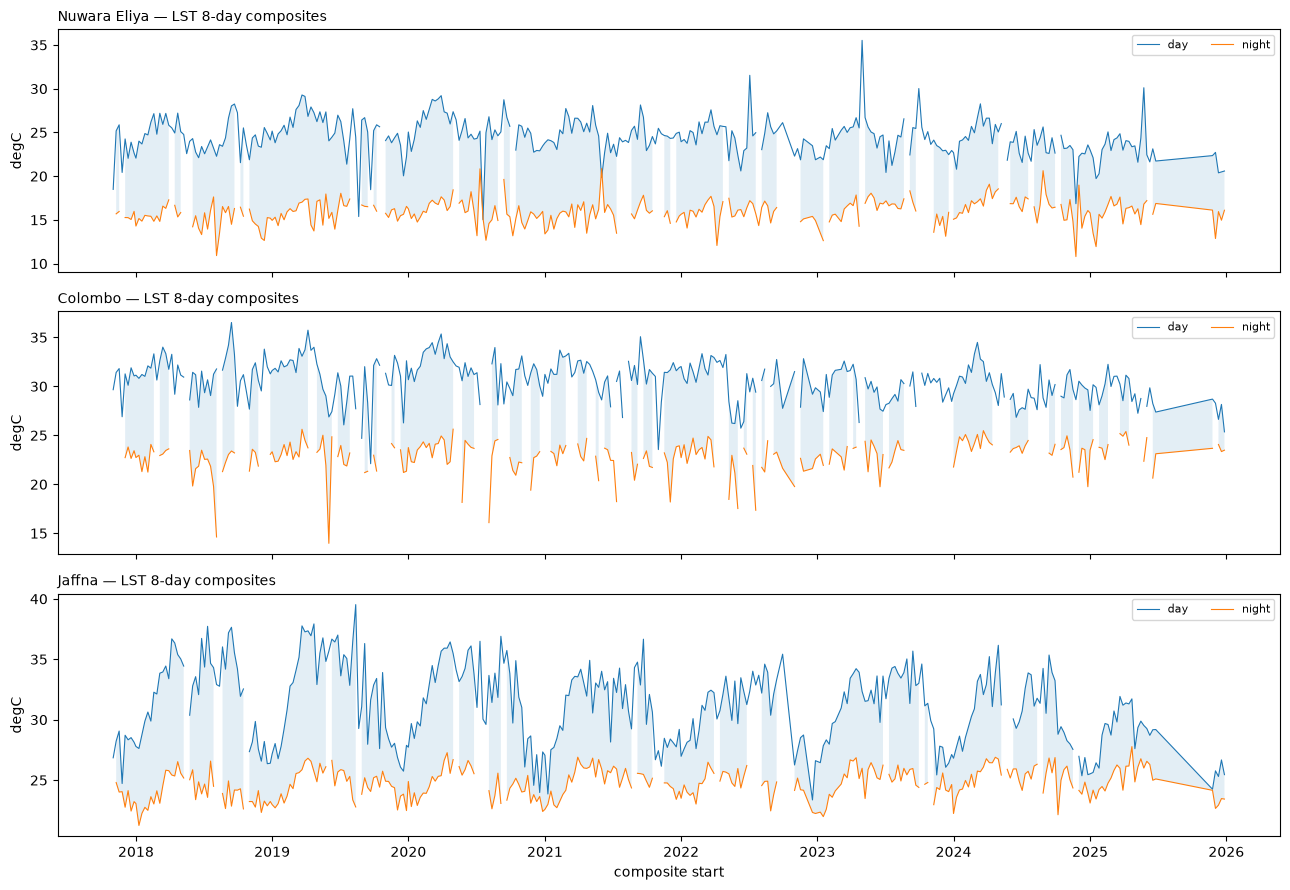

In [14]:
lst["lst_mean"] = lst[["lst_day_mean", "lst_night_mean"]].mean(axis=1)
lst["lst_dtr"]  = lst["lst_day_mean"] - lst["lst_night_mean"]

show = ["Nuwara Eliya", "Colombo", "Jaffna"]
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, name in zip(axes, show):
    d = lst[lst.rdhs_name == name]
    ax.plot(d.composite_start, d.lst_day_mean, lw=.8, label="day")
    ax.plot(d.composite_start, d.lst_night_mean, lw=.8, label="night")
    ax.fill_between(d.composite_start, d.lst_night_mean, d.lst_day_mean, alpha=.12)
    ax.set_ylabel("degC"); ax.set_title(f"{name} — LST 8-day composites", loc="left", fontsize=10)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
axes[-1].set_xlabel("composite start")
plt.tight_layout()

print(lst.groupby("rdhs_name")[["lst_day_mean", "lst_night_mean", "lst_dtr"]]
        .mean().sort_values("lst_day_mean").round(1).to_string())

### The lapse rate, now that the noise has cancelled

Section 9 could only check one composite, where cloud and land cover leave the LST–elevation
correlation around −0.5. Averaged over the whole record those cancel and the physical
relationship should emerge cleanly: a strong negative correlation, and a **lapse rate of roughly
−4 to −7 °C per km**.

This is the strongest end-to-end validation available here. The elevations come from a Copernicus
DEM warped to LAEA in notebook 01; the temperatures come from MODIS thermal bands on a sinusoidal
grid in this one. Nothing links them but the ground. A transposed axis, a misaligned window or a
dropped ×0.02 would all destroy the number below.

corr(mean LST day, elevation) = -0.848   (one composite gave -0.463)
lapse rate, day   = -4.64 degC/km
lapse rate, night = -6.11 degC/km


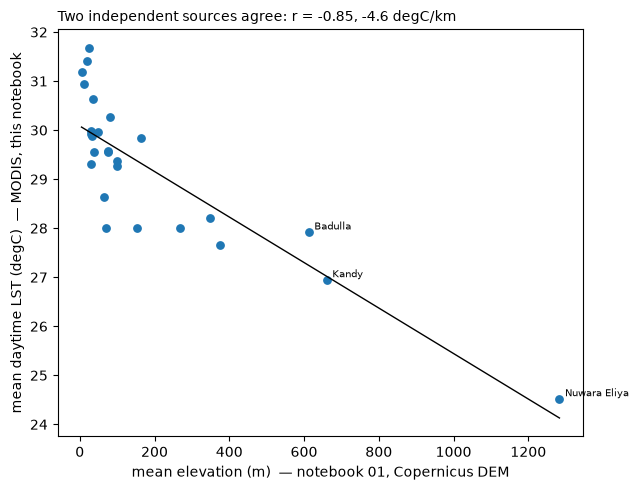

In [15]:
unit_mean = lst.groupby("rdhs_name")[["lst_day_mean", "lst_night_mean"]].mean()
unit_mean = unit_mean.join(terrain.set_index("rdhs_name")["elev_mean"]).dropna()

r_rec = unit_mean["lst_day_mean"].corr(unit_mean["elev_mean"])
lapse = np.polyfit(unit_mean["elev_mean"], unit_mean["lst_day_mean"], 1)[0] * 1000
lapse_n = np.polyfit(unit_mean["elev_mean"], unit_mean["lst_night_mean"], 1)[0] * 1000

print(f"corr(mean LST day, elevation) = {r_rec:.3f}   (one composite gave {r:.3f})")
print(f"lapse rate, day   = {lapse:.2f} degC/km")
print(f"lapse rate, night = {lapse_n:.2f} degC/km")

assert r_rec < -0.8, "averaged LST does not track elevation — the extraction is wrong"
assert -9 < lapse < -2, f"implausible lapse rate {lapse:.1f} degC/km"

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(unit_mean["elev_mean"], unit_mean["lst_day_mean"], s=28)
xs = np.array([unit_mean["elev_mean"].min(), unit_mean["elev_mean"].max()])
b = np.polyfit(unit_mean["elev_mean"], unit_mean["lst_day_mean"], 1)
ax.plot(xs, np.polyval(b, xs), lw=1, color="k")
for n, row in unit_mean.iterrows():
    if row["elev_mean"] > 400 or row["lst_day_mean"] > 34:
        ax.annotate(n, (row["elev_mean"], row["lst_day_mean"]), fontsize=7,
                    xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("mean elevation (m)  — notebook 01, Copernicus DEM")
ax.set_ylabel("mean daytime LST (degC)  — MODIS, this notebook")
ax.set_title(f"Two independent sources agree: r = {r_rec:.2f}, "
             f"{lapse:.1f} degC/km", loc="left", fontsize=10)
plt.tight_layout()

## 12 · Greenness — NDVI and EVI

Same machinery on the 250 m grid. Two differences that matter:

- **Quality comes from `pixel_reliability`**, not packed bits: `0` good, `1` marginal, `2`
  snow/ice, `3` cloud. Keep ≤ 1.
- **EVI as well as NDVI.** NDVI saturates over dense tropical canopy, where much of the wet zone
  sits, and stops discriminating once vegetation is thick. EVI does not saturate as readily. They
  cost one extra band to carry, and which one holds signal is an empirical question, not one to
  settle by assumption here.

In [16]:
def vi_scaled(dn, rel, got):
    """MOD13Q1 -> index units. Fill -3000; valid DN range -2000..10000; scale 1e-4.

    `got` matters more here than for LST: an uncovered pixel reads as DN 0, which is inside
    the valid range and would silently become NDVI 0.0 — a plausible-looking bare-ground value.
    """
    ok = got & (dn >= -2000) & (dn <= 10000) & (rel >= 0) & (rel <= 1)
    return np.where(ok, dn * 1e-4, np.nan)

dn0 = sorted(ndvi_comp)[len(ndvi_comp) // 2]
its0 = ndvi_comp[dn0]
t0 = time.time()
nd0, gv0 = read_placed([i.assets["250m_16_days_NDVI"].href for i in its0], G250)
rel0, _  = read_placed([i.assets["250m_16_days_pixel_reliability"].href for i in its0], G250)
land250 = zones250 > 0
print(f"composite {dn0}: read in {time.time()-t0:.1f}s")
print(f"  land pixels covered: {gv0[land250].mean():.2%}")
for v in np.unique(rel0[land250]):
    print(f"  reliability {v:>4}: {(rel0[land250]==v).mean():6.1%}")
print(f"  kept (<=1): {(np.isfinite(vi_scaled(nd0, rel0, gv0)) & land250).sum()/land250.sum():.1%}")

composite 2021-08-29: read in 3.3s
  land pixels covered: 100.00%
  reliability    0:  30.0%
  reliability    1:  35.5%
  reliability    3:  33.5%
  reliability  255:   1.1%
  kept (<=1): 65.5%


In [17]:
NDVI_CSV = QUAR / "m6_vi_terra_16day_srilanka.csv"

done = set()
if NDVI_CSV.exists():
    done = set(pd.read_csv(NDVI_CSV, usecols=["composite_start"])["composite_start"].astype(str))
todo = [d for d in sorted(ndvi_comp) if d not in done]
print(f"{len(done)} composites cached, {len(todo)} to fetch")

buf, t0 = [], time.time()
for k, date in enumerate(todo, 1):
    its = ndvi_comp[date]
    nd,  gnd = read_placed([i.assets["250m_16_days_NDVI"].href for i in its], G250)
    ev,  gev = read_placed([i.assets["250m_16_days_EVI"].href  for i in its], G250)
    rel, _   = read_placed([i.assets["250m_16_days_pixel_reliability"].href for i in its], G250)

    mnd, snd, fnd = zonal(vi_scaled(nd, rel, gnd), zones250, npx250)
    mev, sev, fev = zonal(vi_scaled(ev, rel, gev), zones250, npx250)

    buf.append(pd.DataFrame({
        "composite_start": date,
        "composite_end":   its[0].properties["end_datetime"][:10],
        "rdhs_id":   rdhs["rdhs_id"].values,
        "rdhs_name": rdhs["rdhs_name"].values,
        "ndvi_mean": mnd, "ndvi_sd": snd, "ndvi_cov": fnd,
        "evi_mean":  mev, "evi_sd":  sev, "evi_cov":  fev,
    }))

    if k % 20 == 0 or k == len(todo):
        pd.concat(buf).to_csv(NDVI_CSV, mode="a", header=not NDVI_CSV.exists(), index=False)
        buf = []
        el = time.time() - t0
        print(f"  {k:>4}/{len(todo)}  {date}  {el/60:.1f} min elapsed, "
              f"~{el/k*(len(todo)-k)/60:.0f} min left")

vi = pd.read_csv(NDVI_CSV).drop_duplicates(["composite_start", "rdhs_id"])
vi["composite_start"] = pd.to_datetime(vi["composite_start"])
vi = vi.sort_values(["rdhs_id", "composite_start"]).reset_index(drop=True)
print(f"\nVI table: {vi.shape}  {vi.composite_start.min().date()} -> "
      f"{vi.composite_start.max().date()}")
vi.head(3)

0 composites cached, 177 to fetch


    20/177  2018-08-29  1.7 min elapsed, ~13 min left


    40/177  2019-07-12  3.3 min elapsed, ~11 min left


    60/177  2020-05-24  4.9 min elapsed, ~10 min left


    80/177  2021-04-07  6.5 min elapsed, ~8 min left


...

   120/177  2023-01-01  10.0 min elapsed, ~5 min left


   140/177  2023-12-03  11.7 min elapsed, ~3 min left


   160/177  2024-10-31  14.3 min elapsed, ~2 min left


   177/177  2025-12-19  16.3 min elapsed, ~0 min left

VI table: (4602, 10)  2017-11-01 -> 2025-12-19


,composite_start,composite_end,rdhs_id,rdhs_name,ndvi_mean,ndvi_sd,ndvi_cov,evi_mean,evi_sd,evi_cov
0,2017-11-01,2017-11-16,RDHS_01,Colombo,0.670573,0.141528,0.757143,0.412543,0.101700,0.757143
1,2017-11-17,2017-12-02,RDHS_01,Colombo,0.669695,0.144722,0.472360,0.353052,0.116768,0.472360
2,2017-12-03,2017-12-18,RDHS_01,Colombo,0.685579,0.139777,0.978183,0.398087,0.107268,0.978183


## 13 · Look at the greenness series

The wet zone should sit high and flat; the northern dry zone should swing hard with the monsoon.
If the dry-zone amplitude were as flat as the wet zone's, the layer would carry no usable
temporal information and we would want to know that here, not after modelling.

               mean     sd  seasonal_amplitude
rdhs_name                                     
Kalmunai      0.607  0.092               0.253
Batticaloa    0.622  0.063               0.174
Killinochchi  0.589  0.062               0.171
Jaffna        0.528  0.063               0.164
Polonnaruwa   0.705  0.050               0.135
Anuradhapura  0.708  0.050               0.133
Kurunegala    0.739  0.049               0.129
Hambantota    0.703  0.052               0.126
Vavuniya      0.732  0.045               0.123
Mannar        0.690  0.050               0.120
Ampara        0.720  0.043               0.119
Colombo       0.685  0.049               0.113
Puttalam      0.711  0.042               0.113
Trincomalee   0.677  0.043               0.111
Mullaitivu    0.706  0.039               0.105
Moneragala    0.751  0.039               0.098
Gampaha       0.732  0.036               0.092
Badulla       0.759  0.030               0.076
Matale        0.768  0.032               0.075
Nuwara Eliya 

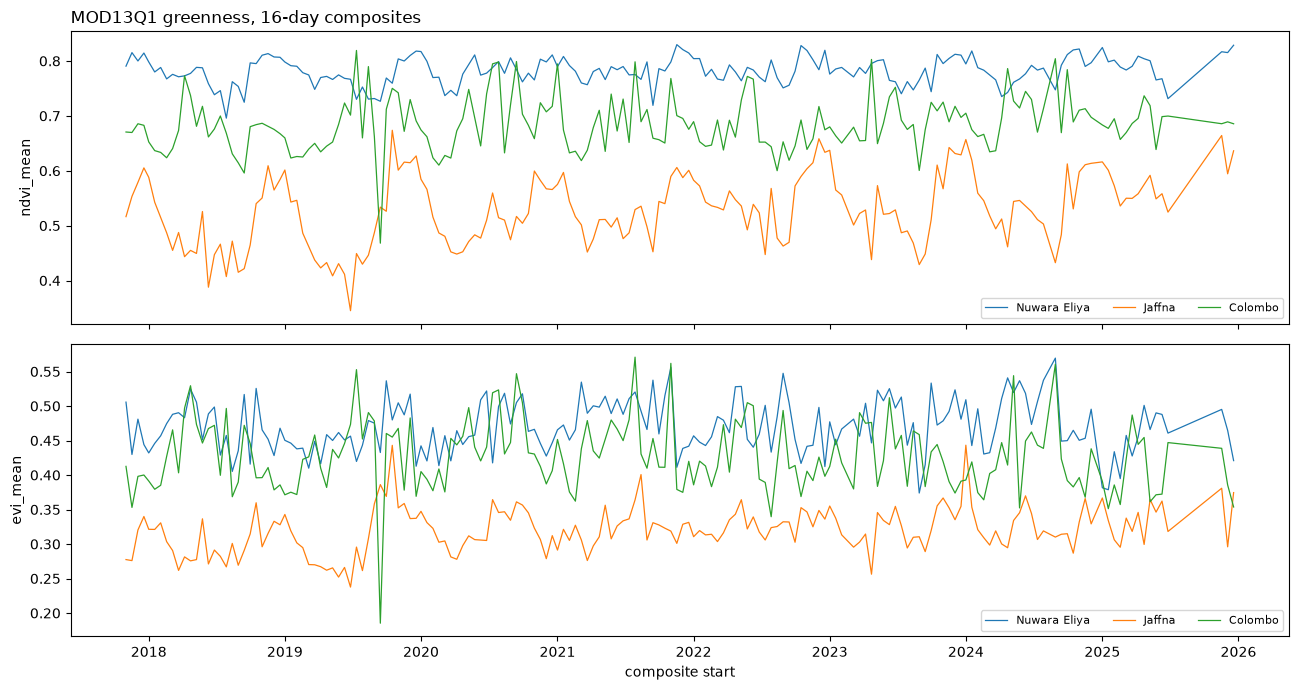

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, col in zip(axes, ["ndvi_mean", "evi_mean"]):
    for name in ["Nuwara Eliya", "Jaffna", "Colombo"]:
        d = vi[vi.rdhs_name == name]
        ax.plot(d.composite_start, d[col], lw=.9, label=name)
    ax.set_ylabel(col); ax.legend(fontsize=8, ncol=3, loc="lower right")
axes[0].set_title("MOD13Q1 greenness, 16-day composites", loc="left")
axes[-1].set_xlabel("composite start")
plt.tight_layout()

amp = (vi.groupby("rdhs_name")["ndvi_mean"]
         .agg(mean="mean", sd="std",
              seasonal_amplitude=lambda s: s.quantile(.9) - s.quantile(.1)))
print(amp.sort_values("seasonal_amplitude", ascending=False).round(3).to_string())

## 14 · Missingness audit

`docs/M6.md` §6 requires a per-feature × unit missingness log, and sets the rule that a dynamic
layer missing more than ~30% for a unit should be dropped or gap-filled rather than quietly
carried. Cloud gaps in a monsoon climate are neither small nor random, so this is the table that
decides how far the LST columns can be trusted.

              lst_day_missing_%  lst_night_missing_%  lst_day_mean_cov_%  ndvi_missing_%  ndvi_mean_cov_%
rdhs_name                                                                                                
Colombo                     4.9                 27.1                62.2             0.0             56.5
Kegalle                     4.3                 18.3                70.1             0.0             70.4
Gampaha                     3.4                 24.9                62.3             0.0             61.4
Matara                      3.4                 18.9                71.1             0.0             69.6
Kalutara                    3.1                 21.1                66.8             0.0             62.4
Galle                       2.6                 21.1                69.0             0.0             62.4
Killinochchi                1.7                  9.4                71.2             0.0             63.7
Nuwara Eliya                1.7               

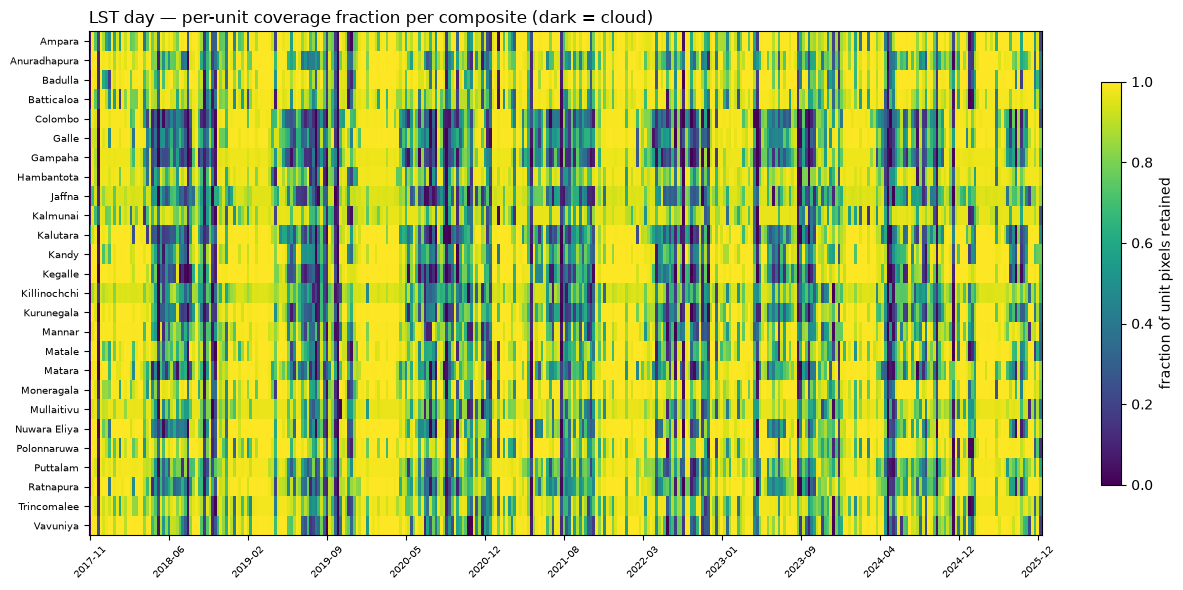

In [19]:
miss = pd.DataFrame({
    "lst_day_missing_%":   lst.groupby("rdhs_name")["lst_day_mean"].apply(lambda s: 100*s.isna().mean()),
    "lst_night_missing_%": lst.groupby("rdhs_name")["lst_night_mean"].apply(lambda s: 100*s.isna().mean()),
    "lst_day_mean_cov_%":  100 * lst.groupby("rdhs_name")["lst_day_cov"].mean(),
    "ndvi_missing_%":      vi.groupby("rdhs_name")["ndvi_mean"].apply(lambda s: 100*s.isna().mean()),
    "ndvi_mean_cov_%":     100 * vi.groupby("rdhs_name")["ndvi_cov"].mean(),
}).round(1).sort_values("lst_day_missing_%", ascending=False)
print(miss.to_string())

over = miss[miss["lst_day_missing_%"] > 30]
print(f"\nunits over the 30% missing-composite threshold: {len(over)}",
      list(over.index) if len(over) else "")

fig, ax = plt.subplots(figsize=(13, 6))
piv = lst.pivot_table(index="rdhs_name", columns="composite_start",
                      values="lst_day_cov", dropna=False)
im = ax.imshow(piv.values, aspect="auto", cmap="viridis", vmin=0, vmax=1,
               interpolation="nearest")
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=7)
step = max(1, len(piv.columns) // 12)
ax.set_xticks(range(0, len(piv.columns), step))
ax.set_xticklabels([str(c)[:7] for c in piv.columns[::step]], rotation=45, fontsize=7)
ax.set_title("LST day — per-unit coverage fraction per composite (dark = cloud)", loc="left")
plt.colorbar(im, ax=ax, shrink=.8, label="fraction of unit pixels retained")
plt.tight_layout()

## 15 · Do these layers actually vary in time?

The question the whole notebook exists to answer. Split each layer's total variance into the part
that separates districts (**between**) and the part that moves within a district over time
(**within**). A static terrain layer is 100% between by construction; that is the null this
notebook has to beat.

If the dynamic layers were also dominated by the between component, M6 would be a cross-sectional
model wearing a time index, and its weekly AUC would be structurally near chance no matter what
the model did. That distinction has to be established **before** the model runs, or a null result
is uninterpretable.

                     total_sd  between_%  within_%
lst_day_mean              3.0       26.2      73.8
lst_night_mean            2.4       57.2      42.8
lst_mean                  2.7       36.2      63.8
lst_dtr                   2.5        6.8      93.2
ndvi_mean                 0.1       71.0      29.0
evi_mean                  0.1       60.5      39.5
elev_mean (static)      285.6      100.0       0.0
slope_mean (static)       4.6      100.0       0.0
twi_mean (static)         1.1      100.0       0.0

A static batch-A layer is 0% within-unit by construction — it cannot express *when*.
The dynamic layers above are what let M6 vary week to week at all.


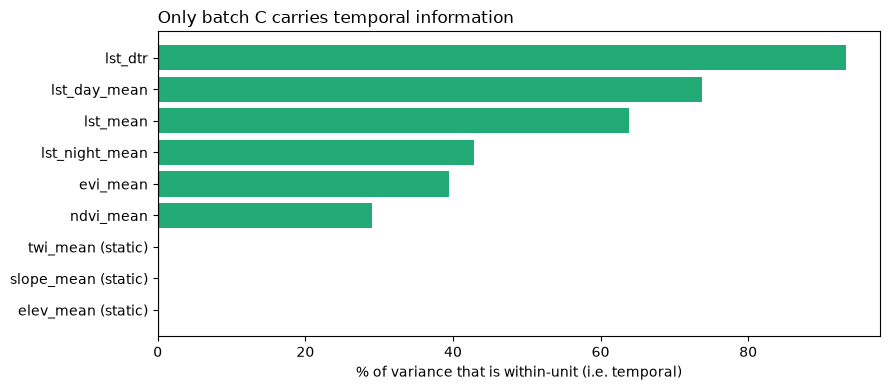

In [20]:
def variance_split(df, col):
    d = df.dropna(subset=[col])
    unit_means = d.groupby("rdhs_id")[col].mean()
    between = unit_means.var(ddof=0)
    within = d.groupby("rdhs_id")[col].var(ddof=0).mean()
    return pd.Series({"total_sd": d[col].std(),
                      "between_%": 100 * between / (between + within),
                      "within_%":  100 * within / (between + within)})

vsplit = {c: variance_split(lst, c)
          for c in ["lst_day_mean", "lst_night_mean", "lst_mean", "lst_dtr"]}
vsplit.update({c: variance_split(vi, c) for c in ["ndvi_mean", "evi_mean"]})

static = terrain.set_index("rdhs_name")[["elev_mean", "slope_mean", "twi_mean"]]
for c in static.columns:
    vsplit[c + " (static)"] = pd.Series({"total_sd": static[c].std(),
                                         "between_%": 100.0, "within_%": 0.0})

split = pd.DataFrame(vsplit).T.round(1)
print(split.to_string())
print("\nA static batch-A layer is 0% within-unit by construction — it cannot express *when*.")
print("The dynamic layers above are what let M6 vary week to week at all.")

fig, ax = plt.subplots(figsize=(9, 4))
s = split.sort_values("within_%")
ax.barh(s.index, s["within_%"], color=["#bbb" if "static" in i else "#2a7" for i in s.index])
ax.set_xlabel("% of variance that is within-unit (i.e. temporal)")
ax.axvline(0, color="k", lw=.8)
ax.set_title("Only batch C carries temporal information", loc="left")
plt.tight_layout()

## 16 · Freeze

Both tables go to quarantine (gitignored — features are never committed) with a provenance record
naming the products, the QA rule and the composite counts that produced them.

The `composite_start` / `composite_end` columns are carried deliberately: notebook 04 must join
these to epi-weeks using only composites that **ended** on or before the week being predicted,
and it cannot enforce that without the end dates.

In [21]:
lst.to_csv(LST_CSV, index=False)     # rewrite deduped + sorted, with derived columns
vi.to_csv(NDVI_CSV, index=False)

prov = {
    "notebook": "02_dynamic_modis",
    "country": "sri_lanka",
    "seed": SEED,
    "window": [WIN_START, WIN_END],
    "lag_preroll_note": "starts 2017-11 so an 8-week lag exists for the first 2018 epi-week",
    "source": "Microsoft Planetary Computer STAC (anonymous SAS signing)",
    "platform_rule": "Terra only (MOD*); Aqua (MYD*) present in the same collections, excluded",
    "duplicate_rule": "one item per (composite, tile); newest `created` wins",
    "modis_tiles": [f"h{h:02d}v{v:02d}" for h, v in TILES],
    "grid_crs": G1K.crs.to_string(),
    "grid_note": "native MODIS sinusoidal (equal-area); data never resampled",
    "lst": {
        "product": "MOD11A2.061", "cadence_days": 8, "res_m": round(G1K.res, 2),
        "bands": ["LST_Day_1km", "QC_Day", "LST_Night_1km", "QC_Night"],
        "qa_rule": "mandatory QA <= 1 AND average LST error bits <= 1 (<= 2 K)",
        "scale": "DN * 0.02 K -> degC", "n_composites": int(len(lst_comp)),
        "rows": int(len(lst)),
        "missing_frac": round(float(lst["lst_day_mean"].isna().mean()), 4),
        "sha256_16": hashlib.sha256(LST_CSV.read_bytes()).hexdigest()[:16],
    },
    "vi": {
        "product": "MOD13Q1.061", "cadence_days": 16, "res_m": round(G250.res, 2),
        "bands": ["250m_16_days_NDVI", "250m_16_days_EVI", "250m_16_days_pixel_reliability"],
        "qa_rule": "pixel_reliability <= 1 (good or marginal)",
        "scale": "DN * 1e-4", "n_composites": int(len(ndvi_comp)),
        "rows": int(len(vi)),
        "missing_frac": round(float(vi["ndvi_mean"].isna().mean()), 4),
        "sha256_16": hashlib.sha256(NDVI_CSV.read_bytes()).hexdigest()[:16],
    },
    "geometry_sha256_16": prov0["geometry_sha256_16"],
}
(QUAR / "nb02_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps(prov, indent=2))

{
  "notebook": "02_dynamic_modis",
  "country": "sri_lanka",
  "seed": 20260612,
  "window": [
    "2017-11-01",
    "2025-12-31"
  ],
  "lag_preroll_note": "starts 2017-11 so an 8-week lag exists for the first 2018 epi-week",
  "source": "Microsoft Planetary Computer STAC (anonymous SAS signing)",
  "platform_rule": "Terra only (MOD*); Aqua (MYD*) present in the same collections, excluded",
  "duplicate_rule": "one item per (composite, tile); newest `created` wins",
  "modis_tiles": [
    "h25v08",
    "h26v08"
  ],
  "grid_crs": "PROJCS[\"unnamed\",GEOGCS[\"Unknown datum based upon the custom spheroid\",DATUM[\"Not specified (based on custom spheroid)\",SPHEROID[\"Custom spheroid\",6371007.181,0]],PRIMEM[\"Greenwich\",0],UNIT[\"degree\",0.0174532925199433,AUTHORITY[\"EPSG\",\"9122\"]]],PROJECTION[\"Sinusoidal\"],PARAMETER[\"longitude_of_center\",0],PARAMETER[\"false_easting\",0],PARAMETER[\"false_northing\",0],UNIT[\"metre\",1,AUTHORITY[\"EPSG\",\"9001\"]],AXIS[\"Easting\",EAST],AXI

## 17 · Recap

In [22]:
recap = pd.DataFrame([
    ("MODIS tiles used",          len(TILES),                     "h25v08, h26v08"),
    ("LST composites",            len(lst_comp),                  "8-day, Terra, 2017-11..2025-12"),
    ("VI composites",             len(ndvi_comp),                 "16-day, Terra"),
    ("LST rows",                  len(lst),                       "composites x 26 units"),
    ("VI rows",                   len(vi),                        "composites x 26 units"),
    ("LST day missing",           f"{100*lst.lst_day_mean.isna().mean():.1f}%", "cloud, after QA"),
    ("NDVI missing",              f"{100*vi.ndvi_mean.isna().mean():.1f}%",     "cloud, after QA"),
    ("mean LST day (island)",     round(float(lst.lst_day_mean.mean()), 1),     "degC"),
    ("mean NDVI (island)",        round(float(vi.ndvi_mean.mean()), 3),         ""),
    ("within-unit variance, LST", f"{split.loc['lst_day_mean','within_%']:.0f}%", "static layers: 0%"),
    ("within-unit variance, NDVI",f"{split.loc['ndvi_mean','within_%']:.0f}%",   "static layers: 0%"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

                  quantity  value                           note
          MODIS tiles used      2                 h25v08, h26v08
            LST composites    350 8-day, Terra, 2017-11..2025-12
             VI composites    177                  16-day, Terra
                  LST rows   9100          composites x 26 units
                   VI rows   4602          composites x 26 units
           LST day missing   1.5%                cloud, after QA
              NDVI missing   0.1%                cloud, after QA
     mean LST day (island)   29.2                           degC
        mean NDVI (island)  0.719                               
 within-unit variance, LST    74%              static layers: 0%
within-unit variance, NDVI    29%              static layers: 0%


---

### Design notes carried forward

**The temporal join is notebook 04's problem, and it is a leakage risk.** An 8-day LST composite
dated 2020-06-01 summarises 2020-06-01 to 2020-06-08. Joining it to the epi-week beginning
2020-06-01 would let a predictor contain observations from *after* the week began. Use only
composites whose `composite_end` precedes the week being predicted, then lag 0–8 weeks from
there — matching M2's climate lag design so the comparison stays like-for-like.

**Gaps must be filled with past data only.** Cloud missingness is heavy in the south-west
(§14). Interpolating a gap from the composites on either side reaches into the future, which is
exactly the leakage the spatial-CV work exists to prevent. Forward-fill, or a climatology built
from earlier years, is safe; `interpolate()` is not.

**Aqua is the obvious sensitivity.** MYD11A2/MYD13Q1 sit in the same collections and would
roughly halve the cloud gaps. Excluded here to keep one overpass time per column; adding it as a
separate column (never merged into the Terra column) is a clean robustness check if missingness
turns out to bind.

**Batch B is still outstanding** — built-up fraction, population density, nightlights,
fragmentation, surface water and forest cover. `docs/M6.md` §9.5 sets an interim gate that fits
M6 on batch A + B before the full ladder, so that notebook is next.